# CDC series catalog generation

Regenerates the CDC **series catalog** in `data/` from the hand-written **registry**
in [`catalog.py`](catalog.py). The registry is CDC's stand-in for BIS's SDMX
structure: ~10 dataset specs (field maps + value-normalization + three
special-case handlers). `export_cdc_catalog()` walks each spec's facet
cross-product and emits **one atomic series per permutation** (~2,500), each
carrying its exact `cdc_series_data` call arguments (`dataset_id` + `where` +
`select`) plus descriptive metadata (concept, unit, span, cadence, provisional,
facets). Output is metadata only — observations are fetched on demand.

`data/*.yaml` is **gitignored and regenerable**, and is consumed by yada's
document store. This notebook uses `CdcClient` **directly** (build-time); it does
**not** need the MCP server running.

In [1]:
%reload_ext autoreload
%autoreload 2

from lib.clients import CdcClient
import catalog

## Generate the catalog

Queries live CDC for the existing facet combinations per dataset (reality-driven,
so suppressed cells never become entries), then writes `data/dataset.yaml` (index)
+ one `cdc_series_<group>.yaml` per source group.

In [2]:
async with CdcClient() as client:
    summary = await catalog.export_cdc_catalog(client, "data")

print("total series:", summary["total"])
summary["by_group"]

total series: 2502


{'w9j2-ggv5': 18,
 'xkb8-kh2a': 424,
 'w26f-tf3h': 28,
 'hksd-2xuw': 1816,
 '9j2v-jamp': 42,
 '489q-934x': 18,
 'le_snapshots': 156}

## Inspect the index

In [3]:
import yaml

index = yaml.safe_load(open("data/dataset.yaml"))
print(f"source: {index['source']}   total: {index['total_series']}\n")
for g in index["groups"]:
    print(f"  {g['group']:16s} {g['series_count']:>5d}  {g['concepts']}")

source: cdc   total: 2502

  w9j2-ggv5           18  ['life_expectancy', 'mortality']
  xkb8-kh2a          424  ['drug_overdose']
  w26f-tf3h           28  ['suicide']
  hksd-2xuw         1816  ['alcohol_binge', 'alcohol_consumption', 'chronic_liver_mortality']
  9j2v-jamp           42  ['suicide']
  489q-934x           18  ['chronic_liver_mortality', 'drug_overdose', 'suicide']
  le_snapshots       156  ['life_expectancy']


## Peek at a series entry

Each entry is directly replayable through the `cdc_series_data` MCP tool — the
top block is the call arguments, the rest is search/display metadata. (LE state
snapshots instead carry a multi-source `sources` list, unioned downstream.)

In [4]:
entry = yaml.safe_load(open("data/cdc_series_w26f-tf3h.yaml"))["series"][0]
entry

{'series_id': 'cdc/suicide/w26f-tf3h/age=15-19/crude',
 'dataset_id': 'w26f-tf3h',
 'where': "`group`='Age group' AND subgroup='15-19 years' AND estimate_type='Deaths per 100,000 resident population, crude'",
 'select': 'time_period AS year, estimate AS value',
 'title': 'suicide (age=15-19, crude)',
 'concept': 'suicide',
 'unit': 'per 100,000',
 'frequency': 'annual',
 'cadence': 'R/P1Y',
 'provisional': False,
 'live': True,
 'facets': {'age': '15-19', 'rate_type': 'crude'},
 'observation_start': '2018',
 'observation_end': '2024'}

## Example — replay a catalog entry through `cdc_series_data`

The **runtime** path (what yada does): read a series' metadata from the catalog,
hand its `dataset_id` / `where` / `select` to the **`cdc_series_data`** MCP tool
(`get_rows` wraps it), and plot — using the entry's own `title` / `unit` for
labels. Unlike the generation cells above (which use `CdcClient` directly), this
one needs the **MCP server running**.

In [5]:
import yaml
from matplotlib import pyplot
from lib import config
from utils import get_rows, plot_cdc_series   # get_rows -> the cdc_series_data MCP tool

pyplot.style.use(config.glyfish_style)

# 1. pull one series' metadata (its cdc_series_data recipe) from the catalog
series = yaml.safe_load(open("data/cdc_series_w9j2-ggv5.yaml"))["series"]
entry = next(e for e in series if e["facets"] == {"race": "all", "sex": "both"})
entry

{'series_id': 'cdc/life_expectancy/w9j2-ggv5/race=all/sex=both',
 'dataset_id': 'w9j2-ggv5',
 'where': "race='All Races' AND sex='Both Sexes'",
 'select': 'year AS year, average_life_expectancy AS value',
 'title': 'life expectancy (race=all, sex=both)',
 'concept': 'life_expectancy',
 'unit': 'years',
 'frequency': 'annual',
 'cadence': 'irregular',
 'provisional': False,
 'live': False,
 'facets': {'race': 'all', 'sex': 'both'},
 'observation_start': '1900',
 'observation_end': '2018'}

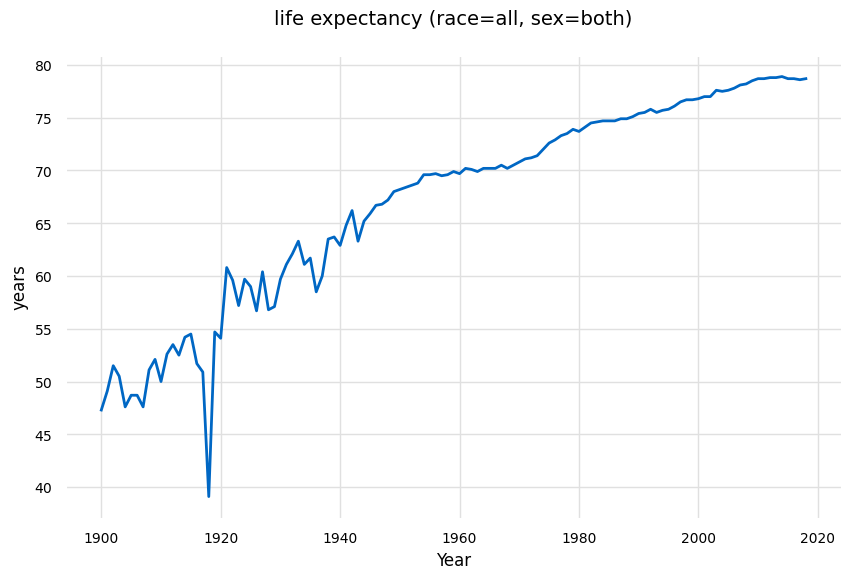

In [6]:
# 2. replay the recipe through cdc_series_data   3. plot with the entry's own metadata
rows = await get_rows(entry["dataset_id"], where=entry["where"], select=entry["select"])

plot_cdc_series(rows, "year", "value", title=entry["title"], ylabel=entry["unit"])